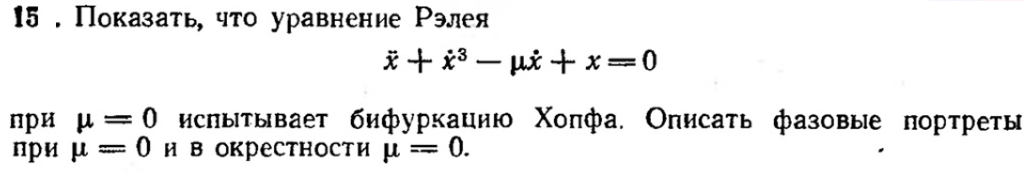

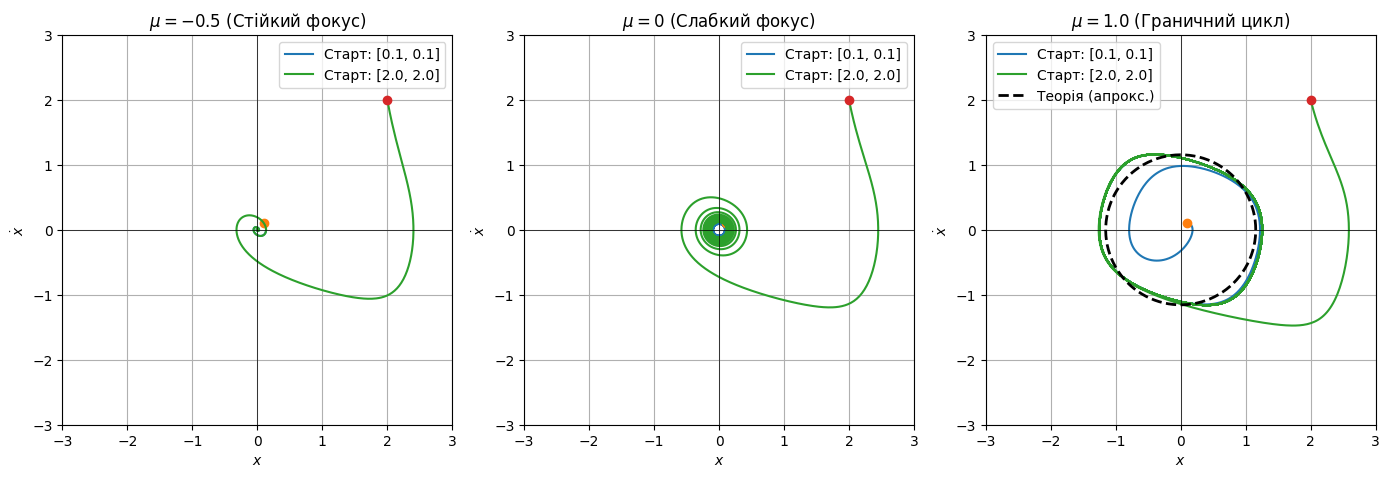

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Визначення системи рівнянь Релея
def rayleigh_system(state, t, mu):
    x, y = state
    dxdt = y
    dydt = -x + mu * y - y**3
    return [dxdt, dydt]

# Параметри часу
t = np.linspace(0, 100, 5000)

# Значення параметра mu для трьох випадків
mu_values = [-0.5, 0, 1.0]
titles = [
    r'$\mu = -0.5$ (Стійкий фокус)',
    r'$\mu = 0$ (Слабкий фокус)',
    r'$\mu = 1.0$ (Граничний цикл)'
]

# Створення графіків
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, mu, title in zip(axes, mu_values, titles):
    # Початкові умови
    initial_conditions = [
        [0.1, 0.1],  # Близько до центру
        [2.0, 2.0],  # Далеко від центру
    ]

    for ic in initial_conditions:
        sol = odeint(rayleigh_system, ic, t, args=(mu,))
        ax.plot(sol[:, 0], sol[:, 1], label=f'Старт: {ic}')
        ax.plot(ic[0], ic[1], 'o') # Точка старту

    # Для mu > 0 додаємо теоретичний граничний цикл
    if mu > 0:
        theta = np.linspace(0, 2*np.pi, 200)
        # Радіус з аналітичного розв'язку: r = sqrt(4*mu / 3)
        r_theor = np.sqrt(4 * mu / 3)
        x_c = r_theor * np.cos(theta)
        y_c = r_theor * np.sin(theta)
        ax.plot(x_c, y_c, 'k--', linewidth=2, label='Теорія (апрокс.)')

    ax.set_title(title)
    ax.set_xlabel('$x$')
    ax.set_ylabel(r'$\dot{x}$ ')
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)
    ax.grid()
    ax.legend()
    ax.set_aspect('equal')

    # Обмеження масштабу
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)

plt.tight_layout()
plt.show()